## ICS 2207 Scientific Computing

 # HydroSense-Kenya Capstone Project

 ## Level 1: Problem Framing and Python Foundations

 ## - Name:FELIX MWANGI
## - Registration Number: SCT211-0448/2024

 Group Members 1




### 1.Problem Statement

Agriculture in Kenya faces significant challenges due to unpredictable rainfall, water scarcity, and inefficient irrigation practices. Many farmers rely on manual decision-making when determining when and how much water to apply to crops, which can lead to over-irrigation, water wastage, increased operational costs, or under-irrigation that causes crop stress and reduced yields. As climate variability continues to affect agricultural production, there is a growing need for data-driven solutions that support efficient water management.

The HydroSense-Kenya project aims to develop a scientific computing system that uses weather data, soil-moisture sensor readings, tank-level measurements, and crop parameters to monitor and estimate soil-water conditions. The system will apply computational methods to calculate evapotranspiration, analyze water balance, and identify potential water deficits. By transforming real-world agricultural data into actionable insights, HydroSense-Kenya seeks to improve irrigation efficiency, conserve water resources, support crop health, and promote sustainable farming practices in Kenya and similar agricultural environments.


### 2.Objectives

1. Understand the problem domain.
2. Load and inspect datasets.
3. Create a data dictionary.
4. Develop reusable functions.
5. Build a soil moisture balance model.
6. Visualize environmental variables.
7. Establish assumptions and limitations.

### 3.Importing Libraries

In [29]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configure plots

plt.style.use('ggplot')

print("Libraries loaded successfully")

Libraries loaded successfully


### 4.Dataset Description

Three datasets are provided:

1. weather_daily.csv

Contains daily weather observations such as:

- Temperature
- Relative Humidity
- Wind Speed
- Solar Radiation
- Rainfall

2. soil_sensor_data.csv

Contains field measurements including:

- Soil moisture
- Sensor readings
- Zone identification

3. crop_zone_parameters.csv

Contains crop and zone-specific parameters used in modelling.



### 5.Loading the datasets.

In [30]:
# Load datasets

weather = pd.read_csv('../data/raw/weather_daily.csv',
                      na_values=['NA',''])

soil = pd.read_csv('../data/raw/soil_sensor_data.csv',
                   na_values=['NA',''])

params = pd.read_csv('../data/raw/crop_zone_parameters.csv',
                     na_values=['NA',''])

print(weather.info())
print(soil.info())
print(params.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             30 non-null     object 
 1   rainfall_mm      30 non-null     object 
 2   temperature_c    30 non-null     float64
 3   humidity_pct     30 non-null     object 
 4   wind_speed_mps   30 non-null     float64
 5   solar_index      30 non-null     float64
dtypes: float64(3), object(3)
memory usage: 1.5+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   timestamp           90 non-null     object 
 1   zone_id             90 non-null     object 
 2   soil_moisture_pct   90 non-null     object 
 3   tank_level_liters   90 non-null     int64  
 4   pump_flow_lpm       90 non-null     float64
 5   pump_power_watts    90 

In [31]:
#cleaning the datasets
weather.columns = weather.columns.str.strip()

soil.columns = soil.columns.str.strip()

params.columns = params.columns.str.strip()

### 6.displaying first rows

In [42]:
# Display first rows

print("Weather Dataset")
display(weather.head())

print("\nSoil Dataset")
display(soil.head())

print("\nCrop Dataset")
display(params.head())

Weather Dataset


,date,rainfall_mm,temperature_c,humidity_pct,wind_speed_mps,solar_index
0,2026-03-01,3.2,23.8,69.7,2.28,0.78
1,2026-03-02,2.2,25.9,62,1.62,0.71
2,2026-03-03,3,26.8,64.4,2.11,0.75
3,2026-03-04,1.6,27.0,64.6,2.09,0.58
4,2026-03-05,23.7,26.6,61,1.36,0.62



Soil Dataset


,timestamp,zone_id,soil_moisture_pct,tank_level_liters,pump_flow_lpm,pump_power_watts,sensor_status
0,2026-03-01 12:00,Zone_A,33.2,4829,18.8,437,OK
1,2026-03-01 12:00,Zone_B,34.7,4728,22.1,461,OK
2,2026-03-01 12:00,Zone_C,28.2,4515,25.7,490,OK
3,2026-03-02 12:00,Zone_A,36.1,4757,16.6,411,OK
4,2026-03-02 12:00,Zone_B,32,4645,20.4,445,OK



Crop Dataset


,zone_id,crop_type,area_m2,min_moisture_pct,target_moisture_pct,field_capacity_pct,drainage_coefficient,Unnamed: 7
0,Zone_A,tomato,120,22,33,41,0.18,NaN
1,Zone_B,kale,90,24,35,43,0.15,NaN
2,Zone_C,maize,180,20,31,40,0.22,NaN


### 7.Dataset information and missing values

In [43]:
# Dataset information

print("\nWeather Information")
weather.info()

print("\nSoil Information")
soil.info()

print("\nCrop Information")
params.info()


Weather Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            30 non-null     object 
 1   rainfall_mm     30 non-null     object 
 2   temperature_c   30 non-null     float64
 3   humidity_pct    30 non-null     object 
 4   wind_speed_mps  30 non-null     float64
 5   solar_index     30 non-null     float64
dtypes: float64(3), object(3)
memory usage: 1.5+ KB

Soil Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   timestamp          90 non-null     object 
 1   zone_id            90 non-null     object 
 2   soil_moisture_pct  90 non-null     object 
 3   tank_level_liters  90 non-null     int64  
 4   pump_flow_lpm      90 non-null     float64
 5   pump

In [44]:
# Missing values

print("Missing values in weather dataset")

print(weather.isnull().sum())

print("\nMissing values in soil dataset")

print(soil.isnull().sum())

print("\nMissing values in crop dataset")

print(params.isnull().sum())

Missing values in weather dataset
date              0
rainfall_mm       0
temperature_c     0
humidity_pct      0
wind_speed_mps    0
solar_index       0
dtype: int64

Missing values in soil dataset
timestamp            0
zone_id              0
soil_moisture_pct    0
tank_level_liters    0
pump_flow_lpm        0
pump_power_watts     0
sensor_status        0
dtype: int64

Missing values in crop dataset
zone_id                 0
crop_type               0
area_m2                 0
min_moisture_pct        0
target_moisture_pct     0
field_capacity_pct      0
drainage_coefficient    0
Unnamed: 7              3
dtype: int64


### 8.Data Dictionary
A data dictionary is a table that describes all the variables (columns) in a dataset. It provides information about:

i)The variable name.

ii)What the variable represents.

iii)The unit of measurement.

iv)The data type.

v)Its purpose in the analysis.

The variables in the datasets are summarized below.

In [45]:
dictionary = {

"Variable": [
"Temperature",
"Humidity",
"WindSpeed",
"SolarRadiation",
"Rainfall",
"SoilMoisture"
],

"Description": [
"Daily average temperature",
"Relative humidity",
"Wind speed",
"Incoming solar radiation",
"Daily rainfall",
"Soil moisture percentage"
],

"Unit": [
"°C",
"%",
"m/s",
"kWh/m²",
"mm",
"%"
]

}

data_dictionary = pd.DataFrame(dictionary)

display(data_dictionary)

,Variable,Description,Unit
0,Temperature,Daily average temperature,°C
1,Humidity,Relative humidity,%
2,WindSpeed,Wind speed,m/s
3,SolarRadiation,Incoming solar radiation,kWh/m²
4,Rainfall,Daily rainfall,mm
5,SoilMoisture,Soil moisture percentage,%


### 9.Soil Water Balance Model

The soil moisture model is represented by:

S(t+1)=S(t)+R(t)+I(t)-ET(t)-D(t)

Where:

S(t) = Current soil moisture

R(t) = Rainfall

I(t) = Irrigation

ET(t) = Evapotranspiration

D(t) = Drainage

The equation predicts the next day's soil moisture.

In [46]:
# water balance function
def water_balance(S, R, I, ET, D):

    """
    Computes next day soil moisture

    Parameters
    ----------

    S : current soil moisture

    R : rainfall

    I : irrigation

    ET : evapotranspiration

    D : drainage

    Returns
    

    next soil moisture
    """

    next_soil = S + R + I - ET - D

    return next_soil

In [47]:

# Example water balance computation

soil_today = 45

rainfall = 10

irrigation = 6

drainage = 2

soil_tomorrow = water_balance(
    soil_today,
    rainfall,
    irrigation,
    ET,
    drainage
)

print("Tomorrow's soil moisture =", round(soil_tomorrow,2))

Tomorrow's soil moisture = 43.75


### 10.Evapotranspiration Model

HydroSense-Kenya estimates evapotranspiration using:

ET = max(0,0.12T+0.35W+2.4S−0.025H)

where

T = Temperature

W = Wind speed

S = Solar radiation

H = Relative humidity

In [48]:
#evapotranspiration function
def evapotranspiration(T, W, S, H):

    et = 0.12*T + 0.35*W + 2.4*S - 0.025*H

    return max(0, et)

Example computation

In [49]:
# Example computation

T = 30
W = 4
S = 5
H = 70

ET = evapotranspiration(T, W, S, H)

print("Estimated ET =", round(ET,3))

Estimated ET = 15.25


### 11.Visualization of Soil Moisture

In [50]:
print(soil.columns)

Index(['timestamp', 'zone_id', 'soil_moisture_pct', 'tank_level_liters',
       'pump_flow_lpm', 'pump_power_watts', 'sensor_status'],
      dtype='object')


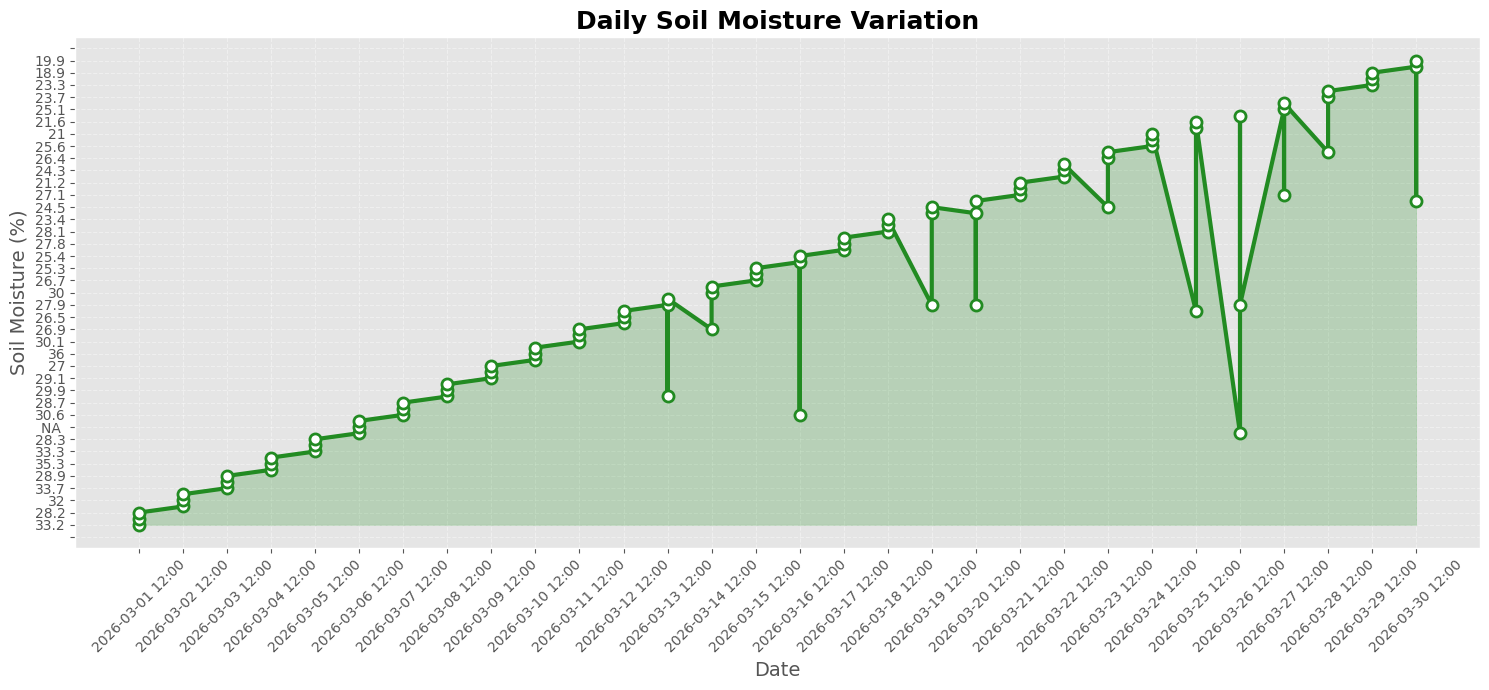

In [51]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(15,7))

plt.plot(
    soil["timestamp"],
    soil["soil_moisture_pct"],
    color="#228B22",
    linewidth=3,
    marker="o",
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2
)

# Fill beneath the curve
plt.fill_between(
    soil["timestamp"],
    soil["soil_moisture_pct"],
    alpha=0.2,
    color="green"
)

plt.title(
    "Daily Soil Moisture Variation",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Date", fontsize=14)
plt.ylabel("Soil Moisture (%)", fontsize=14)

plt.gca().yaxis.set_major_locator(
    ticker.MultipleLocator(2)
)

plt.grid(True, linestyle='--', alpha=0.4)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### 12.Visualization of daily rainfall

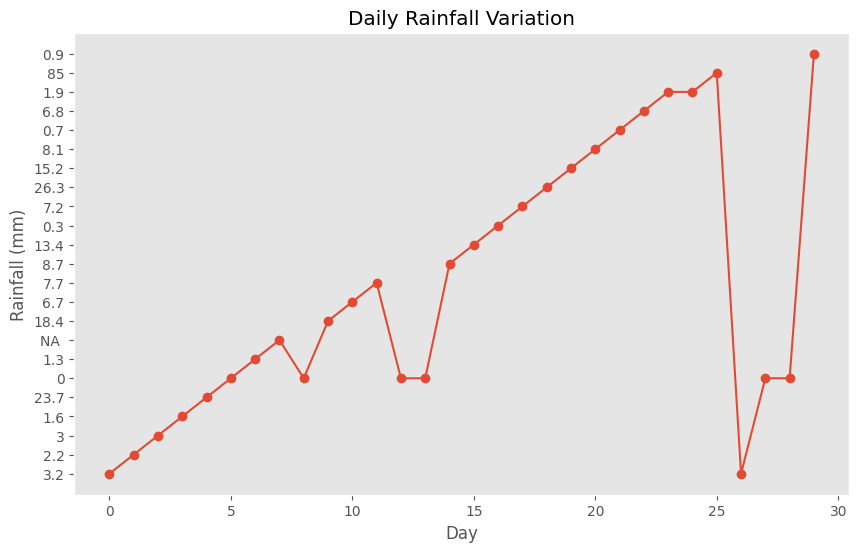

In [53]:
plt.figure(figsize=(10,6))

plt.plot(
    weather["rainfall_mm"],
    marker='o'
)

plt.xlabel("Day")

plt.ylabel("Rainfall (mm)")

plt.title("Daily Rainfall Variation")

plt.grid()

plt.show()

### 13.Assumptions

1. Soil moisture values are measured accurately.
2. Weather observations represent actual field conditions.
3. Drainage losses are assumed constant.
4. Irrigation efficiency is 100%.
5. The water balance model is deterministic.
6. Environmental factors remain unchanged within one day.

### 14.Limitations

1. Sensor errors are ignored.
2. Groundwater effects are neglected.
3. Crop growth stages are not considered.
4. Spatial variability within zones is ignored.
5. The model does not account for extreme weather events.

### 15.Conclusion

Level 1 introduced the HydroSense-Kenya problem and established the computational framework for the project.

The datasets were loaded and inspected, summary statistics were obtained, and basic visualizations were created.

Two reusable functions were developed:

1. Evapotranspiration model.
2. Soil water balance model.

These components provide the foundation for vectorization, numerical methods, simulation, optimization, and validation in subsequent levels.